# Keyword trend modeling (final)

Predicts next-year change in a word's share of thesis titles within a subject,
for words already flagged as rising by the EDA method.

**Target:** `dshare = share(t+1) - share(t)`

**Leak-free by construction:**
- Rising-word candidates selected using only data up to `SELECT_END`
- Specificity and all rolling features computed cumulatively (up to year t only)
- Panel is zero-filled (a year without the word counts as share = 0)
- Sample weights = next-year title-word volume

**KPIs:** RMSE (primary), MAE, direction accuracy, NDCG on change. See `kpis.md`.

**Inputs:** `data/word_year_subject_v5_final.parquet`, `data/subject_meta_v5_final.parquet`.


In [1]:
# %% [imports]
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, ndcg_score
from sklearn.utils import shuffle

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
Path("images").mkdir(exist_ok=True)


C:\Users\Work\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.stats import gaussian_kde


In [2]:
# %% [load]
PIPELINE_VERSION = "v5_final"   # must match the build_parquets run this reads from
raw  = pd.read_parquet(f"data/word_year_subject_{PIPELINE_VERSION}.parquet")
meta = pd.read_parquet(f"data/subject_meta_{PIPELINE_VERSION}.parquet")
print(f"Loaded parquet: {len(raw):,} rows | {raw['subject'].nunique()} subjects")


Loaded parquet: 445,666 rows | 63 subjects


In [3]:
# %% [derive year window from the data]
# START_YEAR: first year with enough token volume to trust
# TREND_END:  last year before the recent data-entry lag drop-off

MIN_VOLUME_PER_YEAR = 1_000
LAG_DROP_FRAC       = 0.75

_syt_all = raw.groupby(["subject", "year"])["total_title_words"].first().reset_index()
year_volume = _syt_all.groupby("year")["total_title_words"].sum().sort_index()

START_YEAR = int(year_volume[year_volume >= MIN_VOLUME_PER_YEAR].index.min())
peak_year  = int(year_volume.idxmax())
peak_val   = int(year_volume.max())
tail       = year_volume[year_volume.index >= peak_year]
TREND_END  = int(tail[tail >= LAG_DROP_FRAC * peak_val].index.max())

print(f"Peak year:  {peak_year} ({peak_val:,} title-words)")
print(f"START_YEAR: {START_YEAR}")
print(f"TREND_END:  {TREND_END}")


Peak year:  2013 (26,778 title-words)
START_YEAR: 1954
TREND_END:  2021


In [4]:
# %% [parameters]
TEST_YEARS  = 10
SELECT_END  = TREND_END - TEST_YEARS   # candidates chosen using data <= this year
SPLIT_YEAR  = SELECT_END + 1           # train < SPLIT_YEAR, test >= SPLIT_YEAR

MIN_YEAR_WORDS = 50
MIN_TOTAL      = 10
SPEC_MIN       = 1.5
RECENT         = 10
TOP_K          = 10

assert SELECT_END < SPLIT_YEAR, "selection must not see the test window"

FEATURES = ["share_lag1", "share_lag2", "share_lag3",
            "slope_3yr", "slope_5yr", "accel", "vol_5yr",
            "spec_cum", "word_age", "log_volume"]

print(f"SELECT_END={SELECT_END} | SPLIT_YEAR={SPLIT_YEAR} | TREND_END={TREND_END}")


SELECT_END=2011 | SPLIT_YEAR=2012 | TREND_END=2021


In [5]:
# %% [filter to usable rows]
df = raw[
    (raw["year"] >= START_YEAR) &
    (raw["year"] <= TREND_END) &
    (raw["total_title_words"] >= MIN_YEAR_WORDS)
].copy()

subj_year_tot = (
    df.groupby(["subject", "year"])["total_title_words"]
    .first().rename("total").reset_index()
)
print(f"Filtered rows: {len(df):,} | subjects: {df['subject'].nunique()} "
      f"| years {df['year'].min()}-{df['year'].max()}")


Filtered rows: 366,056 | subjects: 55 | years 1954-2021


In [6]:
# %% [leak-free rising-word selection]
# Same idea as the EDA notebook's method, but computed strictly from data <= end_year.

def select_rising_pairs(d, syt, end_year,
                        recent=RECENT, min_total=MIN_TOTAL,
                        spec_min=SPEC_MIN, top_k=TOP_K):
    d = d[d["year"] <= end_year]

    pair_tot  = d.groupby(["subject", "word"])["count"].sum()
    subj_tot  = d.groupby("subject")["count"].sum()
    glob_word = d.groupby("word")["count"].sum()
    glob_tot  = glob_word.sum()

    cand = pair_tot[pair_tot >= min_total].reset_index()
    subj_share = cand["count"] / cand["subject"].map(subj_tot)
    glob_share = cand["word"].map(glob_word) / glob_tot
    cand["spec"] = subj_share / np.maximum(glob_share, 1e-9)
    cand = cand[cand["spec"] >= spec_min]

    years = np.arange(end_year - recent + 1, end_year + 1)
    dr = d[d["year"].isin(years)]
    counts = (
        dr.pivot_table(index=["subject", "word"], columns="year",
                       values="count", aggfunc="sum")
        .reindex(columns=years).fillna(0.0)
    )
    counts = counts.join(
        pd.DataFrame(index=cand.set_index(["subject", "word"]).index),
        how="inner")
    totals = (
        syt[syt["year"].isin(years)]
        .pivot(index="subject", columns="year", values="total")
        .reindex(columns=years)
    )
    tot_aligned = totals.reindex(counts.index.get_level_values("subject")).values
    shares = counts.values / np.where(np.isnan(tot_aligned) | (tot_aligned == 0),
                                      np.nan, tot_aligned)
    valid = (~np.isnan(shares)).sum(axis=1) >= 5

    x  = np.arange(recent, dtype=float)
    xc = x - x.mean()
    sh = np.nan_to_num(shares, nan=0.0)
    slope = (sh @ xc) / (xc @ xc) * 10 * 100   # %-points per decade

    out = counts.index.to_frame(index=False)
    out["recent_slope"] = slope
    out = out[valid]
    out = out.merge(cand[["subject", "word", "spec", "count"]]
                    .rename(columns={"count": "total"}),
                    on=["subject", "word"])
    out["enriched"] = (out["recent_slope"] * out["spec"]
                       / np.log1p(glob_word[out["word"]].values))

    # underscore-aware prefix dedup within subject (keep higher total)
    def dedup(g):
        keep = []
        for w in g.sort_values("total", ascending=False)["word"]:
            w_parts = w.split("_")
            dominated = any(
                k.split("_") == w_parts[:len(k.split("_"))] or
                w_parts == k.split("_")[:len(w_parts)]
                for k in keep
            )
            if not dominated:
                keep.append(w)
        return g[g["word"].isin(keep)]

    out = out.query("recent_slope > 0")
    out = pd.concat([dedup(g) for _, g in out.groupby("subject")], ignore_index=True)
    return (out.sort_values("enriched", ascending=False)
            .groupby("subject").head(top_k)
            .reset_index(drop=True))

rising = select_rising_pairs(df, subj_year_tot, end_year=SELECT_END)
pairs  = rising[["subject", "word"]].drop_duplicates()
print(f"Rising pairs selected as of {SELECT_END}: {len(pairs)} "
      f"across {pairs['subject'].nunique()} subjects")


Rising pairs selected as of 2011: 402 across 48 subjects


In [7]:
# %% [feature panel builder -- shared by training, CV, and watchlist]

def rolling_slope(s, window):
    def _s(x):
        if np.any(np.isnan(x)):
            return np.nan
        return np.polyfit(range(len(x)), x, 1)[0]
    return s.rolling(window).apply(_s, raw=True)

def build_feature_panel(d, syt, pair_df):
    grid = pair_df.merge(syt, on="subject")
    pn = (grid.merge(d[["subject", "word", "year", "count"]],
                     on=["subject", "word", "year"], how="left")
          .fillna({"count": 0}))
    pn["share"] = pn["count"] / pn["total"]
    pn = pn.sort_values(["subject", "word", "year"]).reset_index(drop=True)

    g = pn.groupby(["subject", "word"], sort=False)
    pn["share_lag1"] = g["share"].shift(1)
    pn["share_lag2"] = g["share"].shift(2)
    pn["share_lag3"] = g["share"].shift(3)
    pn["slope_3yr"]  = g["share"].transform(lambda s: rolling_slope(s, 3))
    pn["slope_5yr"]  = g["share"].transform(lambda s: rolling_slope(s, 5))
    pn["accel"]      = pn["slope_3yr"] - pn["slope_5yr"]
    pn["vol_5yr"]    = g["share"].transform(lambda s: s.rolling(5).std())

    first_seen = (pn[pn["count"] > 0].groupby(["subject", "word"])["year"]
                  .min().rename("first_year"))
    pn = pn.merge(first_seen, on=["subject", "word"], how="left")
    pn["word_age"]   = (pn["year"] - pn["first_year"]).clip(lower=0)
    pn["log_volume"] = np.log1p(pn["total"])

    # cumulative (leak-free) specificity
    g = pn.groupby(["subject", "word"], sort=False)
    pn["cum_count"] = g["count"].cumsum()
    sc = syt.sort_values(["subject", "year"]).copy()
    sc["subj_cum_tot"] = sc.groupby("subject")["total"].cumsum()
    pn = pn.merge(sc[["subject", "year", "subj_cum_tot"]], on=["subject", "year"])

    words = pair_df["word"].unique()
    gw = (d[d["word"].isin(words)]
          .groupby(["word", "year"])["count"].sum().rename("gcount").reset_index())
    yg = (pn[["word", "year"]].drop_duplicates()
          .merge(gw, on=["word", "year"], how="left").fillna({"gcount": 0})
          .sort_values(["word", "year"]))
    yg["g_cum"] = yg.groupby("word")["gcount"].cumsum()
    gt = d.groupby("year")["count"].sum().rename("gtot").reset_index().sort_values("year")
    gt["gtot_cum"] = gt["gtot"].cumsum()
    yg = yg.merge(gt[["year", "gtot_cum"]], on="year")
    pn = pn.merge(yg[["word", "year", "g_cum", "gtot_cum"]], on=["word", "year"])
    pn["spec_cum"] = (
        (pn["cum_count"] / pn["subj_cum_tot"].clip(lower=1))
        / np.maximum(pn["g_cum"] / pn["gtot_cum"].clip(lower=1), 1e-9)
    )

    g = pn.groupby(["subject", "word"], sort=False)
    pn["share_next"] = g["share"].shift(-1)
    pn["total_next"] = g["total"].shift(-1)
    pn["dshare"]     = pn["share_next"] - pn["share"]
    return pn

panel = build_feature_panel(df, subj_year_tot, pairs)
dm = panel.dropna(subset=FEATURES + ["dshare", "total_next"]).copy()
print(f"Panel rows: {len(panel):,} | model-ready rows: {len(dm):,}")


Panel rows: 17,547 | model-ready rows: 15,537


In [8]:
# %% [KPI helpers -- one function per metric, one row per (fold, model)]

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def direction_accuracy(y_true, y_pred):
    nz = y_true != 0
    if nz.sum() == 0:
        return np.nan
    return float((np.sign(y_pred[nz]) == np.sign(y_true[nz])).mean())

def ndcg_on_change(test_df, y_pred, min_group=5):
    tc = test_df.copy()
    tc["pred"] = y_pred
    scores = []
    for (_, _), grp in tc.groupby(["subject", "year"]):
        if len(grp) < min_group:
            continue
        rel = grp["dshare"].values
        rel = rel - rel.min()   # ndcg needs non-negative relevance
        scores.append(ndcg_score([rel], [grp["pred"].values]))
    return float(np.mean(scores)) if scores else np.nan

def score_all(name, test_df, y_pred):
    y_true = test_df["dshare"].values
    return {
        "model": name,
        "RMSE": rmse(y_true, y_pred),
        "MAE": mae(y_true, y_pred),
        "dir_acc": direction_accuracy(y_true, y_pred),
        "NDCG": ndcg_on_change(test_df, y_pred),
    }


In [9]:
# %% [time-series cross-validation]
# Expanding-window CV: for each fold, train on years < fold_split, test on
# fold_split..fold_split + TEST_YEARS - 1. Selection is redone leak-free
# inside each fold using data <= fold_split - 1.

CV_SPLITS = [
    (2004, 2005, 2015),   # (select_end, split_year, test_end)
    (2007, 2008, 2018),
    (2009, 2010, 2020),
    (SELECT_END, SPLIT_YEAR, TREND_END),
]

def run_fold(select_end, split_year, test_end):
    d_f  = raw[(raw["year"] >= START_YEAR) & (raw["year"] <= test_end) &
               (raw["total_title_words"] >= MIN_YEAR_WORDS)].copy()
    syt  = (d_f.groupby(["subject", "year"])["total_title_words"]
            .first().rename("total").reset_index())
    p    = select_rising_pairs(d_f, syt, end_year=select_end)[["subject", "word"]]
    pn   = build_feature_panel(d_f, syt, p)
    dm_f = pn.dropna(subset=FEATURES + ["dshare", "total_next"]).copy()

    tr = dm_f[dm_f["year"] <  split_year]
    te = dm_f[dm_f["year"] >= split_year]
    if len(tr) < 200 or len(te) < 200:
        return None

    X_tr, y_tr, w_tr = tr[FEATURES].values, tr["dshare"].values, tr["total_next"].values
    X_te             = te[FEATURES].values

    results = []

    # trivial: DummyRegressor (predicts training mean)
    dum = DummyRegressor(strategy="mean").fit(X_tr, y_tr, sample_weight=w_tr)
    results.append(score_all("Dummy (mean)", te, dum.predict(X_te)))

    # trivial (domain): zero-change
    results.append(score_all("Zero-change", te, np.zeros(len(te))))

    # domain: momentum
    results.append(score_all("Momentum (slope_3yr)", te, te["slope_3yr"].values))

    # linear: Ridge on standardized features, sample-weighted
    sc = StandardScaler()
    r  = Ridge(alpha=1.0)
    r.fit(sc.fit_transform(X_tr), y_tr, sample_weight=w_tr)
    results.append(score_all("Ridge (weighted)", te, r.predict(sc.transform(X_te))))

    # tree-based: HistGBR
    gbr = HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05,
                                        max_iter=400, random_state=42)
    gbr.fit(X_tr, y_tr, sample_weight=w_tr)
    results.append(score_all("HistGBR (weighted)", te, gbr.predict(X_te)))

    for r_row in results:
        r_row["fold"] = f"{split_year}-{test_end}"
    return results

all_rows = []
for se, sp, en in CV_SPLITS:
    fold = run_fold(se, sp, en)
    if fold:
        all_rows.extend(fold)

cv_df = pd.DataFrame(all_rows)
print(f"CV folds run: {cv_df['fold'].nunique()} | rows: {len(cv_df)}")
cv_df.round(4)


C:\Users\Work\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Work\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
 

CV folds run: 4 | rows: 20


,model,RMSE,MAE,dir_acc,NDCG,fold
0,Dummy (mean),0.0089,0.0051,0.4957,0.8099,2005-2015
1,Zero-change,0.0089,0.0051,0.0000,0.8099,2005-2015
2,Momentum (slope_3yr),0.0119,0.0069,0.3381,0.7231,2005-2015
3,Ridge (weighted),0.0069,0.0043,0.6978,0.9086,2005-2015
4,HistGBR (weighted),0.0072,0.0044,0.7006,0.8942,2005-2015
5,Dummy (mean),0.0098,0.0057,0.4955,0.8049,2008-2018
6,Zero-change,0.0098,0.0057,0.0000,0.8049,2008-2018
7,Momentum (slope_3yr),0.0131,0.0078,0.3344,0.7239,2008-2018
8,Ridge (weighted),0.0078,0.0049,0.7027,0.9076,2008-2018
9,HistGBR (weighted),0.0083,0.0050,0.6927,0.8877,2008-2018


In [10]:
# %% [KPI summary table -- mean and std across folds]
kpi_summary = (
    cv_df.groupby("model")[["RMSE", "MAE", "dir_acc", "NDCG"]]
    .agg(["mean", "std"])
    .round(4)
)
# reorder rows so trivial baselines are on top
model_order = ["Dummy (mean)", "Zero-change", "Momentum (slope_3yr)",
               "Ridge (weighted)", "HistGBR (weighted)"]
kpi_summary = kpi_summary.reindex(model_order)
print(kpi_summary)
kpi_summary.to_csv(f"data/kpi_summary_{PIPELINE_VERSION}.csv")


                        RMSE             MAE         dir_acc            NDCG  \
                        mean     std    mean     std    mean     std    mean   
model                                                                          
Dummy (mean)          0.0099  0.0008  0.0057  0.0005  0.4929  0.0058  0.8095   
Zero-change           0.0099  0.0008  0.0057  0.0005  0.0000  0.0000  0.8095   
Momentum (slope_3yr)  0.0132  0.0010  0.0078  0.0006  0.3289  0.0086  0.7241   
Ridge (weighted)      0.0078  0.0007  0.0049  0.0004  0.6978  0.0059  0.9129   
HistGBR (weighted)    0.0082  0.0007  0.0050  0.0004  0.6967  0.0034  0.8986   

                              
                         std  
model                         
Dummy (mean)          0.0032  
Zero-change           0.0032  
Momentum (slope_3yr)  0.0022  
Ridge (weighted)      0.0056  
HistGBR (weighted)    0.0092  


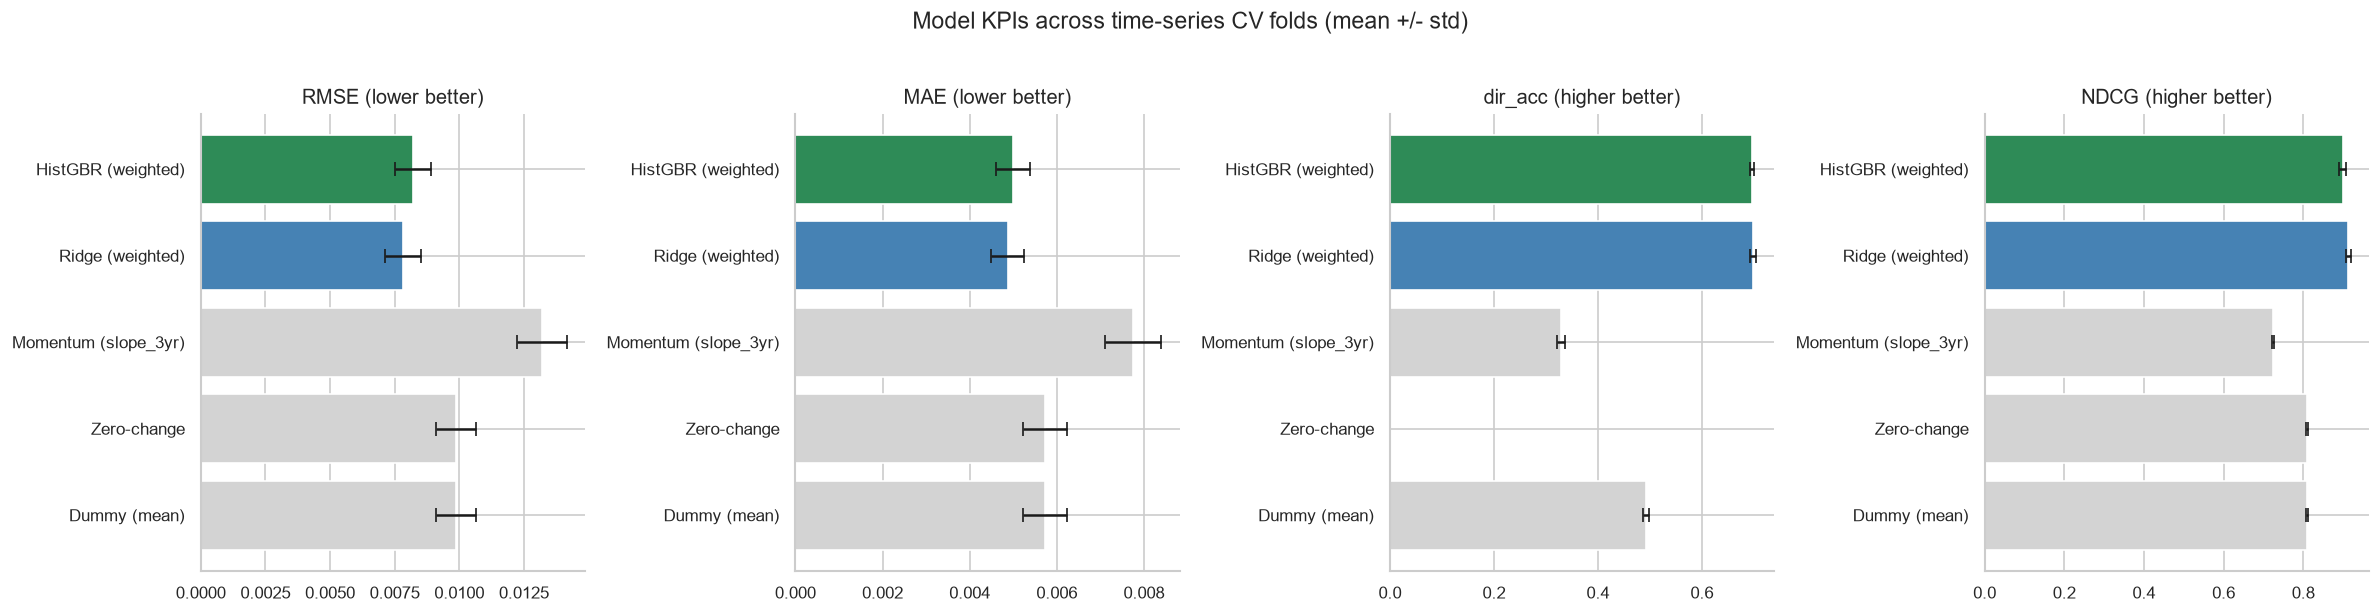

In [11]:
# %% [figure: KPI comparison across models]
means = cv_df.groupby("model")[["RMSE", "MAE", "dir_acc", "NDCG"]].mean().reindex(model_order)
stds  = cv_df.groupby("model")[["RMSE", "MAE", "dir_acc", "NDCG"]].std().reindex(model_order)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
colors = ["lightgray", "lightgray", "lightgray", "steelblue", "seagreen"]

for ax, kpi in zip(axes, ["RMSE", "MAE", "dir_acc", "NDCG"]):
    ax.barh(means.index, means[kpi], xerr=stds[kpi], color=colors,
            edgecolor="white", capsize=4)
    ax.set_title(kpi + (" (lower better)" if kpi in ("RMSE", "MAE")
                        else " (higher better)"), fontsize=12)
    ax.tick_params(labelsize=10)
    sns.despine(ax=ax)

fig.suptitle("Model KPIs across time-series CV folds (mean +/- std)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("images/model_kpi_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


In [12]:
# %% [detailed run on the final fold -- for feature importance and diagnostics]
train = dm[dm["year"] <  SPLIT_YEAR]
test  = dm[dm["year"] >= SPLIT_YEAR]
print(f"Train: {len(train):,} rows | {train['year'].min()}-{train['year'].max()}")
print(f"Test:  {len(test):,} rows | {test['year'].min()}-{test['year'].max()}")

X_tr, y_tr, w_tr = train[FEATURES].values, train["dshare"].values, train["total_next"].values
X_te, y_te       = test[FEATURES].values,  test["dshare"].values

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

ridge = Ridge(alpha=1.0)
ridge.fit(X_tr_s, y_tr, sample_weight=w_tr)
pred_ridge = ridge.predict(X_te_s)

coefs = (pd.DataFrame({"feature": FEATURES, "coef": ridge.coef_})
         .sort_values("coef", key=abs, ascending=False))
print(coefs.to_string(index=False))


Train: 11,977 rows | 1958-2011
Test:  3,560 rows | 2012-2020
   feature      coef
share_lag2 -0.005700
share_lag1  0.004827
 slope_3yr -0.003678
 slope_5yr -0.003469
     accel -0.002254
   vol_5yr -0.001188
share_lag3  0.000994
  word_age  0.000263
log_volume -0.000219
  spec_cum  0.000037


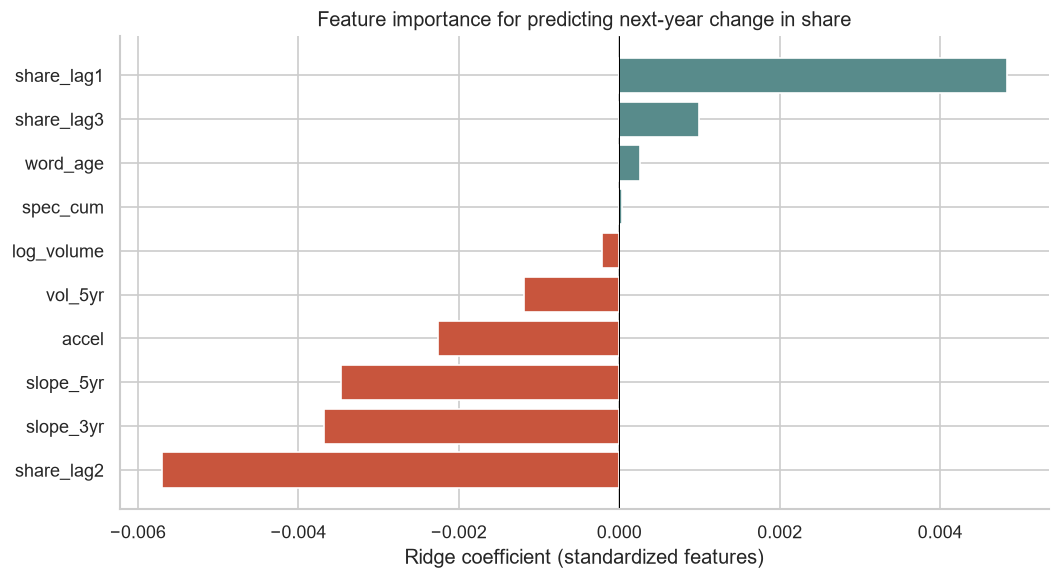

In [13]:
# %% [figure: Ridge feature coefficients on the final fold]
d = coefs.sort_values("coef")
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#c8553d" if c < 0 else "#588b8b" for c in d["coef"]]
ax.barh(d["feature"], d["coef"], color=colors, edgecolor="white")
ax.axvline(0, color="black", lw=0.6)
ax.set_xlabel("Ridge coefficient (standardized features)")
ax.set_title("Feature importance for predicting next-year change in share")
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("images/model_feature_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()


In [14]:
# %% [leakage checks]
# 1. shuffled-target sanity: features shouldn't predict a randomized target
r_sh = Ridge(alpha=1.0)
r_sh.fit(X_tr_s, shuffle(y_tr, random_state=42), sample_weight=w_tr)
rmse_sh = np.sqrt(mean_squared_error(y_te, r_sh.predict(X_te_s)))
print(f"Shuffled-target RMSE = {rmse_sh:.6f} (should be >= zero-change RMSE)")

# 2. selection-leak probe: what if we had chosen candidates using ALL data
rising_leaky = select_rising_pairs(df, subj_year_tot, end_year=TREND_END)
overlap = len(pairs.merge(rising_leaky[["subject", "word"]], on=["subject", "word"]))
print(f"Overlap clean vs full-window selection: {overlap}/{len(pairs)} pairs "
      f"({overlap/len(pairs):.0%})")
print("The gap is what selecting with future data would have quietly used.")


Shuffled-target RMSE = 0.010856 (should be >= zero-change RMSE)
Overlap clean vs full-window selection: 83/402 pairs (21%)
The gap is what selecting with future data would have quietly used.


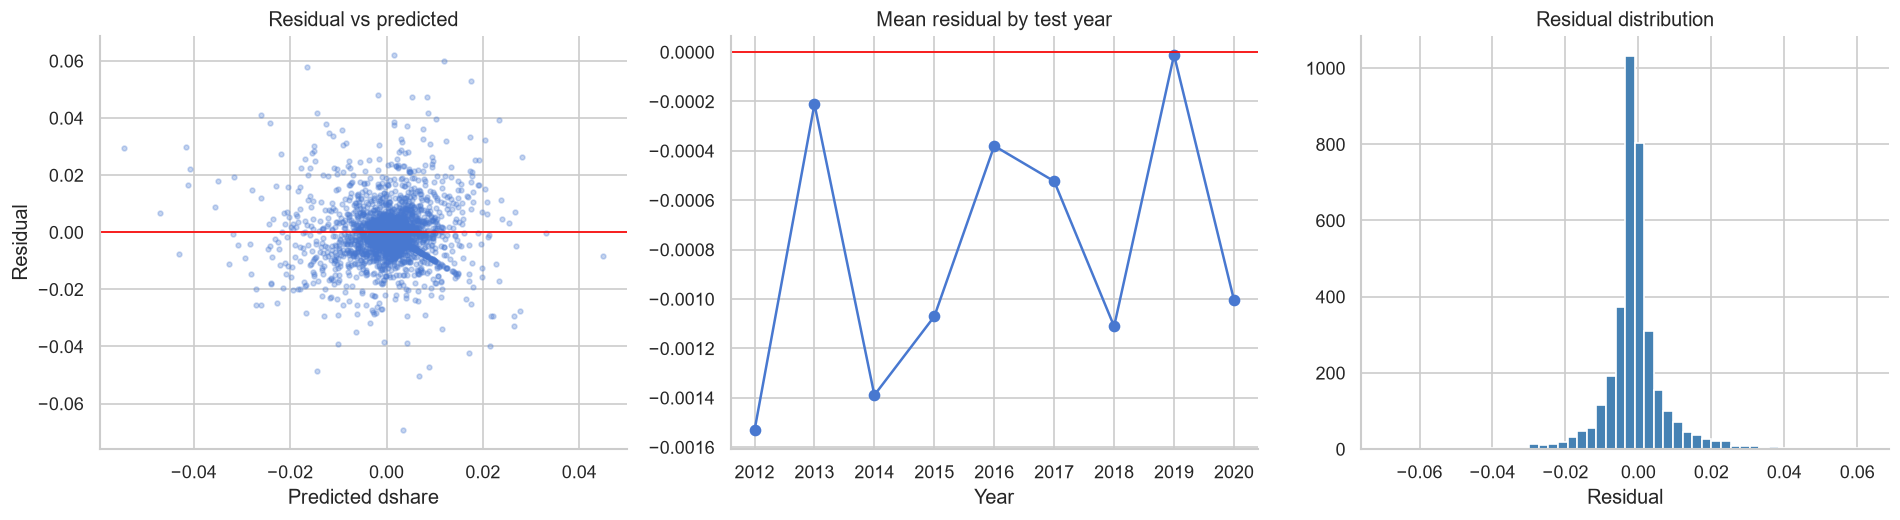

In [15]:
# %% [residual diagnostics]
tc = test.copy()
tc["pred"] = pred_ridge
tc["residual"] = y_te - pred_ridge

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].scatter(pred_ridge, tc["residual"], alpha=0.3, s=8)
axes[0].axhline(0, color="red", lw=1)
axes[0].set_xlabel("Predicted dshare"); axes[0].set_ylabel("Residual")
axes[0].set_title("Residual vs predicted")

tc.groupby("year")["residual"].mean().plot(ax=axes[1], marker="o")
axes[1].axhline(0, color="red", lw=1)
axes[1].set_title("Mean residual by test year")
axes[1].set_xlabel("Year")

axes[2].hist(tc["residual"], bins=50, color="steelblue", edgecolor="white")
axes[2].set_title("Residual distribution")
axes[2].set_xlabel("Residual")

sns.despine()
plt.tight_layout()
plt.savefig("images/model_residual_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()


In [16]:
# %% [watchlist for TREND_END + 1]
# Deployment step: candidates selected with full data allowed, since we
# are making forward predictions now, not evaluating.
rising_now = select_rising_pairs(df, subj_year_tot, end_year=TREND_END)
pairs_now  = rising_now[["subject", "word"]].drop_duplicates()

panel_now = build_feature_panel(df, subj_year_tot, pairs_now)
latest = panel_now[panel_now["year"] == TREND_END].dropna(subset=FEATURES).copy()

# refit on ALL leak-free rows for deployment
sc_f = StandardScaler()
r_f  = Ridge(alpha=1.0)
r_f.fit(sc_f.fit_transform(dm[FEATURES]), dm["dshare"], sample_weight=dm["total_next"])

latest["pred_dshare"] = r_f.predict(sc_f.transform(latest[FEATURES]))
latest["pred_share"]  = latest["share"] + latest["pred_dshare"]

watch = latest.merge(meta, on="subject")
top5 = (watch.sort_values("pred_dshare", ascending=False)
        .groupby("subject_name").head(5)
        [["subject_name", "word", "share", "pred_share", "pred_dshare",
          "slope_3yr", "spec_cum"]]
        .sort_values(["subject_name", "pred_dshare"], ascending=[True, False])
        .reset_index(drop=True))
top5.to_csv(f"data/watchlist_{TREND_END + 1}_{PIPELINE_VERSION}.csv", index=False)
print(f"Saved watchlist: {len(top5)} words, {top5['subject_name'].nunique()} subjects")
top5.head(20)


Saved watchlist: 230 words, 46 subjects


,subject_name,word,share,pred_share,pred_dshare,slope_3yr,spec_cum
0,Algebraic geometry,enumerative,0.000000,0.003495,0.003495,-1.557632e-03,29.453352
1,Algebraic geometry,derive_category,0.002841,0.003841,0.001000,-9.159941e-04,38.871317
2,Algebraic geometry,modulus,0.005682,0.006525,0.000843,-2.743557e-04,32.439881
3,Algebraic geometry,grassmannian,0.002841,0.003580,0.000739,-1.371779e-04,29.297101
4,Algebraic geometry,chow,0.002841,0.003438,0.000597,-2.473626e-03,48.144903
5,Algebraic topology,equivariant,0.005076,0.015937,0.010861,-1.406709e-02,50.465054
6,Algebraic topology,configuration,0.000000,0.006641,0.006641,-3.690037e-03,25.816679
7,Algebraic topology,simplicial,0.000000,0.005490,0.005490,-1.845018e-03,61.529752
8,Algebraic topology,complement,0.000000,0.003054,0.003054,-1.845018e-03,32.539773
9,Algebraic topology,persistent,0.005076,0.007344,0.002268,-4.842003e-03,57.787334


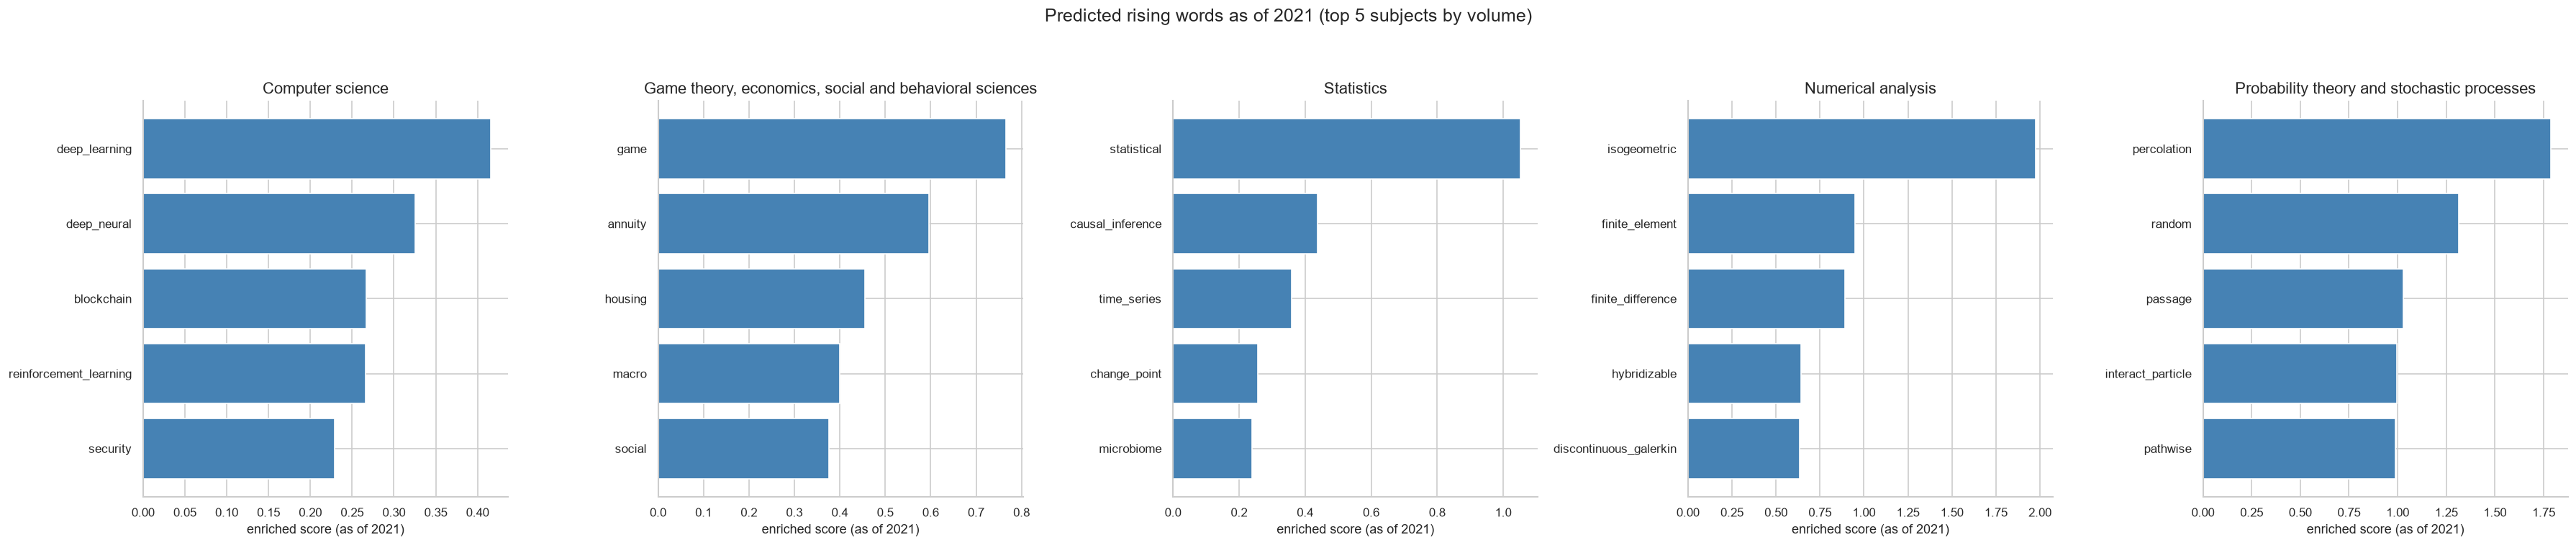

In [22]:
# %% [figure: predicted rising words for TREND_END + 1]
# Uses the same enriched score as the actuals plot below, so the two are
# directly comparable. Selection is done at end_year = TREND_END (deployment:
# full data allowed here since we are making a forward prediction).

FORECAST_YEAR = TREND_END + 1
PLOT_SUBJECTS = 5

# same subject ordering used in actuals plot
subject_rank = (
    meta.sort_values("n_titles", ascending=False)
    .head(PLOT_SUBJECTS)["subject_name"]
    .tolist()
)

rising_forecast = select_rising_pairs(df, subj_year_tot, end_year=TREND_END)
forecast = rising_forecast.merge(meta, on="subject")

fig, axes = plt.subplots(1, PLOT_SUBJECTS, figsize=(6 * PLOT_SUBJECTS, 6))

for ax, subj in zip(axes, subject_rank):
    sub = (forecast[forecast["subject_name"] == subj]
           .nlargest(5, "enriched")
           .sort_values("enriched"))
    ax.barh(sub["word"], sub["enriched"], color="steelblue", edgecolor="white")
    ax.set_title(subj, fontsize=13)
    ax.set_xlabel(f"enriched score (as of {TREND_END})", fontsize=11)
    ax.tick_params(labelsize=10)
    sns.despine(ax=ax)

fig.suptitle(f"Predicted rising words as of {TREND_END} "
             f"(top {PLOT_SUBJECTS} subjects by volume)", fontsize=15, y=1.05)
plt.tight_layout()
plt.savefig(f"images/watchlist_{FORECAST_YEAR}_top_subjects.png",
            dpi=150, bbox_inches="tight")
plt.show()

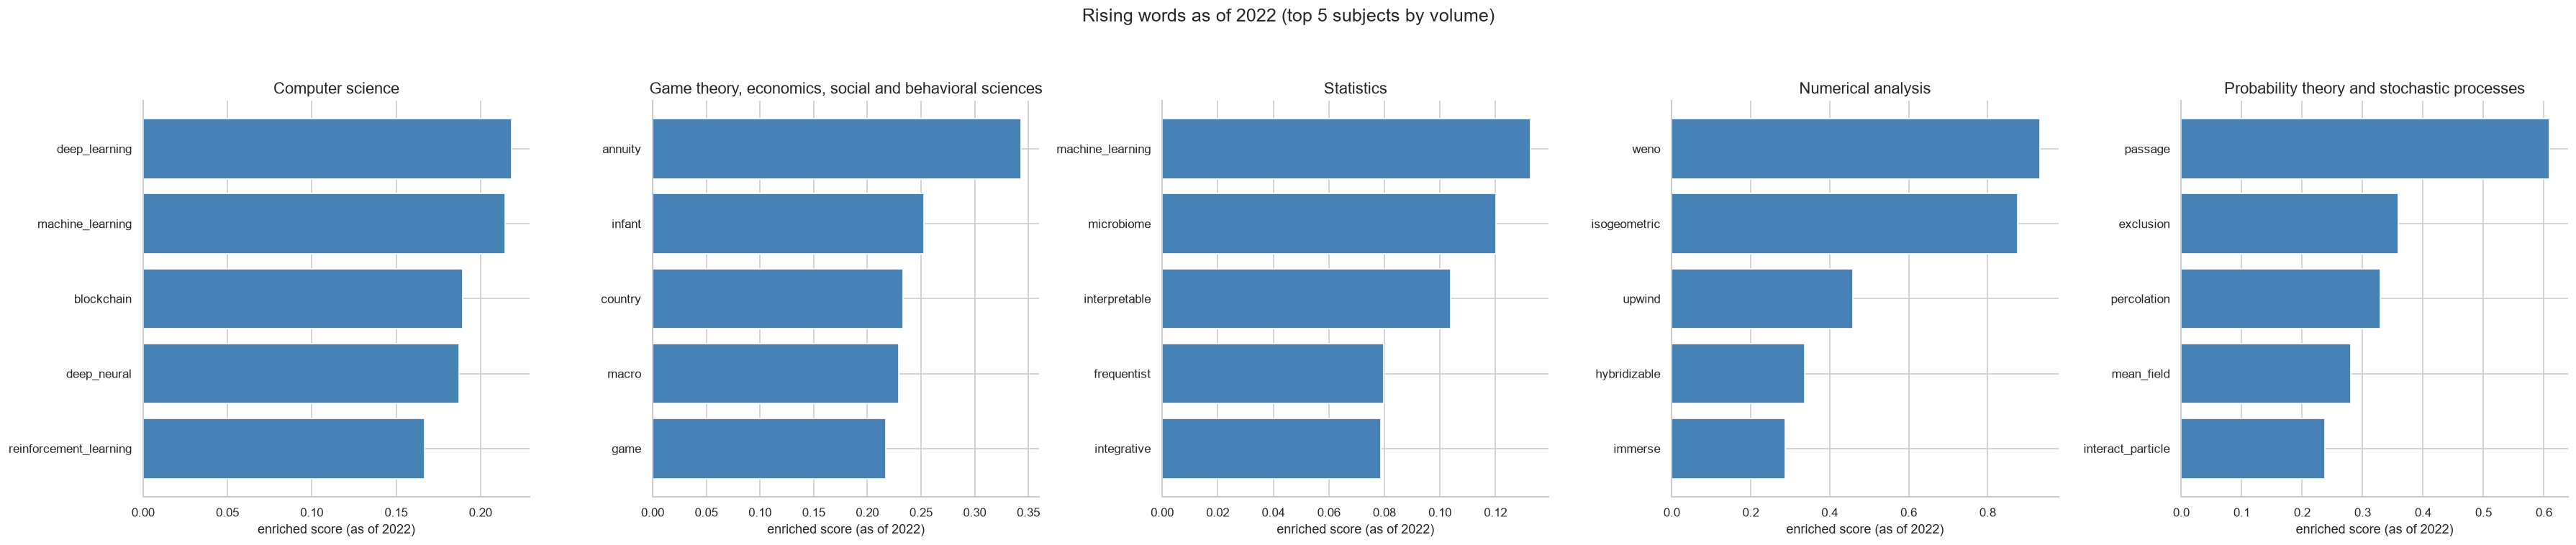

In [23]:
# %% [figure: actual rising words at an earlier year, for comparison]
COMPARE_YEAR = 2022

rising_actual = select_rising_pairs(df, subj_year_tot, end_year=COMPARE_YEAR)
actual = rising_actual.merge(meta, on="subject")

fig, axes = plt.subplots(1, PLOT_SUBJECTS, figsize=(6 * PLOT_SUBJECTS, 6))

for ax, subj in zip(axes, subject_rank):
    sub = (actual[actual["subject_name"] == subj]
           .nlargest(5, "enriched")
           .sort_values("enriched"))
    ax.barh(sub["word"], sub["enriched"], color="steelblue", edgecolor="white")
    ax.set_title(subj, fontsize=13)
    ax.set_xlabel(f"enriched score (as of {COMPARE_YEAR})", fontsize=11)
    ax.tick_params(labelsize=10)
    sns.despine(ax=ax)

fig.suptitle(f"Rising words as of {COMPARE_YEAR} "
             f"(top {PLOT_SUBJECTS} subjects by volume)", fontsize=15, y=1.05)
plt.tight_layout()
plt.savefig(f"images/actual_rising_{COMPARE_YEAR}_top_subjects.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Reading the results

- Ridge should beat both trivial baselines (Dummy, Zero-change) on RMSE and MAE.
- Ridge should beat momentum (`slope_3yr`) on direction accuracy and NDCG,
  otherwise the extra features are not adding value over a simple rule.
- HistGBR usually lands close to Ridge on this task, since the relationship
  is approximately linear once share lags are included. If GBR wins by a
  large margin, that's a sign to look at nonlinear interactions.
- The shuffled-target RMSE in the leakage check should be at or above the
  zero-change RMSE. If it's noticeably lower, there is feature-target leakage.

See `kpis.md` for KPI definitions and directions of improvement.
